## Experiment Setup
Configure model/persona and base directories for personalization comparison.


In [26]:
from pathlib import Path
import json
import warnings
from typing import List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configurable parameters
BASE_SCORE_DIR = "<PROJECT_ROOT>/Desktop/Desktop - ADUAED19365LPMX/Agent_IX_Personalization/gorilla/berkeley-function-call-leaderboard/LLM_as_judge_score"
MODEL_NAME = "claude_opus_4_5_20251101_FC"  # Set to your desired model

# claude_opus_4_5_20251101_FC
# claude_sonnet_4_5_20250929_FC
# gemini_3_flash_FC
# kimi_k2_0905_preview_FC

JUDGE_NAMES = [
    "anthropic_claude-opus-4.5",
    "anthropic_claude-sonnet-4.5",
    "google_gemini-3-flash-preview",
    "moonshotai_kimi-k2-0905"
]



# Auto-enumerate persona names to avoid omissions
import os
PERSONAS = [
    "chain_parallel",
    "chain_sequential",
    "confirmation_batch",
    "disambiguation_gradual",
    "disambiguation_upfront",
    "each_confirmation",
    "error_discovery_brief",
    "error_discovery_detail",
    "error_retry_escalation",
    "error_retry_silent",
    "info_collect_gradual",
    "info_collect_upfront",
    "param_high",
    "param_low",
    "param_medium",
    "presentation_compact",
    "presentation_layered",
    "silent",
    "source_high",
    "source_low",
    "tool_abortion_continue",
    "tool_abortion_stop",
    "tool_high",
    "tool_initiative_proactive",
    "tool_initiative_reactive",
    "tool_invocation_multiple",
    "tool_invocation_single",
    "tool_low",
    "tool_medium",
    "tool_switch_high_agency",
    "tool_switch_low_agency"
]

# Also adjust the directory check section:
for judge_name in JUDGE_NAMES:
    for persona in PERSONAS:
        no_personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "no_personalization" / persona
        personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "personalization" / persona
        # If the directory doesn't exist, skip without raising an error
        for p in [no_personalization_dir, personalization_dir]:
            if not p.exists():
                warnings.warn(f"Skip missing directory: {p}", UserWarning)
                continue
            if not any(p.iterdir()):
                warnings.warn(f"Directory exists but is empty, skipping: {p}", UserWarning)
                continue

# Fixed dimensions in judge output
DIMENSIONS: List[str] = [
    "initiative_timing",
    "interaction_coherence",
    "intent_alignment_drift",
    "commitment_consistency",
    "interaction_preference_alignment",
    "interaction_efficiency",
    "user_cognitive_load_trajectory",
    "overall_user_experience",
]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Loading
Load judge JSON outputs (fixed 7 dimensions) for personalization vs. no_personalization.


In [27]:
def load_scores(directory: Path, persona: str = None) -> pd.DataFrame:
    files = sorted(directory.glob("*_judge.json"))
    if not files:
        raise FileNotFoundError(f"No *_judge.json files found in {directory}")
    rows = []
    for fp in files:
        try:
            content = json.loads(fp.read_text(encoding="utf-8"))
        except json.JSONDecodeError as exc:
            warnings.warn(f"Failed to parse JSON for {fp.name}: {exc}")
            continue

        # Compatible with multiple schemas
        parsed = content.get("parsed")
        if isinstance(parsed, dict) and parsed.get("dimensions"):
            # New format: content["parsed"]["dimensions"]
            dims_block = parsed.get("dimensions") or {}
        else:
            # Fallback 1: top-level "dimensions"
            dims_block = content.get("dimensions") or {}

            # Fallback 2: legacy format with single dimension/score
            if not dims_block:
                dim_name = content.get("dimension")
                score_val = content.get("score")
                if dim_name in DIMENSIONS and isinstance(score_val, (int, float)):
                    dims_block = {
                        dim_name: {
                            "score": float(score_val),
                            # Include other fields if present (optional)
                            "justification": content.get("justification", ""),
                            "evidence_turn_ids": content.get("evidence_turn_ids", []),
                        }
                    }
                else:
                    dims_block = {}

        row = {"test_id": fp.stem.replace("_judge", "")}
        if persona:
            row["persona"] = persona  # Add persona column for tracking
        
        for dim in DIMENSIONS:
            dim_entry = dims_block.get(dim)
            score = None if dim_entry is None else dim_entry.get("score")
            if isinstance(score, (int, float)):
                row[dim] = float(score)
            else:
                warnings.warn(
                    f"Missing/invalid score for '{dim}' in {fp.name}; set NaN"
                )
                row[dim] = np.nan
        rows.append(row)

    if not rows:
        raise ValueError(f"No valid records loaded from {directory}")
    columns = ["test_id"] + (["persona"] if persona else []) + DIMENSIONS
    return pd.DataFrame(rows, columns=columns)

In [28]:
# Directory/empty-dir checks already done in (1-87); only load and concat here, no extra warnings or existence checks
# Use a dict to store data for multiple judge models

no_personalization_data = {}
personalization_data = {}

for judge_name in JUDGE_NAMES:
    no_personalization_dfs = []
    personalization_dfs = []

    for persona in PERSONAS:
        no_personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "no_personalization" / persona
        personalization_dir = Path(BASE_SCORE_DIR) / judge_name / MODEL_NAME / "personalization" / persona

        try:
            no_df = load_scores(no_personalization_dir, persona=persona)
            no_personalization_dfs.append(no_df)
        except Exception:
            pass

        try:
            personalization_df = load_scores(personalization_dir, persona=persona)
            personalization_dfs.append(personalization_df)
        except Exception:
            pass

    if no_personalization_dfs:
        no_personalization_data[judge_name] = pd.concat(no_personalization_dfs, ignore_index=True)
    else:
        warnings.warn(f"No valid no_personalization data found for {judge_name}")

    if personalization_dfs:
        personalization_data[judge_name] = pd.concat(personalization_dfs, ignore_index=True)
    else:
        warnings.warn(f"No valid personalization data found for {judge_name}")

print(f"Loaded data for {len(no_personalization_data)} judge models: {list(no_personalization_data.keys())}")

/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_59737/660769016.py:48: UserWarning: Missing/invalid score for 'interaction_preference_alignment' in multi_turn_long_context_104_judge.json; set NaN
  warnings.warn(


Loaded data for 4 judge models: ['anthropic_claude-opus-4.5', 'anthropic_claude-sonnet-4.5', 'google_gemini-3-flash-preview', 'moonshotai_kimi-k2-0905']


/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_59737/660769016.py:48: UserWarning: Missing/invalid score for 'intent_alignment_drift' in multi_turn_miss_param_50_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_59737/660769016.py:48: UserWarning: Missing/invalid score for 'interaction_coherence' in multi_turn_miss_param_51_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_59737/660769016.py:48: UserWarning: Missing/invalid score for 'user_cognitive_load_trajectory' in multi_turn_miss_param_150_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_59737/660769016.py:48: UserWarning: Missing/invalid score for 'commitment_consistency' in multi_turn_miss_param_51_judge.json; set NaN
  warnings.warn(
/var/folders/h0/hg82lwhs2l1bvq786x_jh8xh0000gs/T/ipykernel_59737/660769016.py:48: UserWarning: Missing/invalid score for 'intent_alignment_drift' in

In [29]:
# Show the first judge's data as an example
if JUDGE_NAMES and JUDGE_NAMES[0] in personalization_data:
    print(f"First judge ({JUDGE_NAMES[0]}) personalization data:")
    personalization_data[JUDGE_NAMES[0]]
else:
    print("No data available for first judge")

First judge (anthropic_claude-opus-4.5) personalization data:


In [30]:
# Show the first judge's data as an example
if JUDGE_NAMES and JUDGE_NAMES[0] in no_personalization_data:
    print(f"First judge ({JUDGE_NAMES[0]}) no_personalization data:")
    no_personalization_data[JUDGE_NAMES[0]]
else:
    print("No data available for first judge")

First judge (anthropic_claude-opus-4.5) no_personalization data:


In [31]:
# Clean data for each judge model (drop rows with NaN across all 7 dimensions)
for judge_name in JUDGE_NAMES:
    if judge_name in no_personalization_data:
        no_personalization_data[judge_name] = no_personalization_data[judge_name].dropna()
    if judge_name in personalization_data:
        personalization_data[judge_name] = personalization_data[judge_name].dropna()

print("Data cleaning completed for all judge models")

Data cleaning completed for all judge models


In [32]:
# During data validation, ensure test_id/persona fully align and dimensions match
# Output non-overlapping test_id/persona to help debug

def check_alignment(df1, df2, label1, label2):
    """Ensure two DataFrames fully align on the test_id+persona key"""
    set1 = set(zip(df1["test_id"], df1["persona"]))
    set2 = set(zip(df2["test_id"], df2["persona"]))
    only1 = set1 - set2
    only2 = set2 - set1
    if only1:
        print(f"{label1} unique (not in {label2}):", sorted(only1))
    if only2:
        print(f"{label2} unique (not in {label1}):", sorted(only2))
    if not only1 and not only2:
        print(f"{label1} 与 {label2} test_id/persona fully aligned")

# Then ensure all dimension columns match
def check_schema(df1, df2):
    dims1 = set(DIMENSIONS) & set(df1.columns)
    dims2 = set(DIMENSIONS) & set(df2.columns)
    if dims1 != dims2:
        print("Warning: dimension names differ between the two datasets!")
        print("only in df1:", dims1 - dims2)
        print("only in df2:", dims2 - dims1)
    else:
        print("All dimension fields match:", dims1)

# Check alignment for each judge model
for judge_name in JUDGE_NAMES:
    if judge_name not in no_personalization_data or judge_name not in personalization_data:
        print(f"Skipping alignment check for {judge_name} (missing data)")
        continue
    
    print(f"\n=== Alignment check for {judge_name} ===")
    check_alignment(
        no_personalization_data[judge_name], 
        personalization_data[judge_name], 
        "no_personalization_df", 
        "personalization_df"
    )
    check_schema(no_personalization_data[judge_name], personalization_data[judge_name])



=== Alignment check for anthropic_claude-opus-4.5 ===
personalization_df 独有 (未出现在 no_personalization_df): [('multi_turn_long_context_104', 'each_confirmation')]
所有维度字段一致： {'interaction_coherence', 'interaction_preference_alignment', 'overall_user_experience', 'user_cognitive_load_trajectory', 'interaction_efficiency', 'initiative_timing', 'intent_alignment_drift', 'commitment_consistency'}

=== Alignment check for anthropic_claude-sonnet-4.5 ===
no_personalization_df 与 personalization_df 的 test_id/persona 完全对齐
所有维度字段一致： {'interaction_coherence', 'interaction_preference_alignment', 'overall_user_experience', 'user_cognitive_load_trajectory', 'interaction_efficiency', 'initiative_timing', 'intent_alignment_drift', 'commitment_consistency'}

=== Alignment check for google_gemini-3-flash-preview ===
no_personalization_df 独有 (未出现在 personalization_df): [('multi_turn_long_context_114', 'tool_high'), ('multi_turn_long_context_127', 'chain_sequential'), ('multi_turn_long_context_182', 'chain_s

## Data Validation
Ensure test IDs overlap and dimensions align (fixed schema).


In [33]:
# Create merged data for each judge model
merged_data = {}

for judge_name in JUDGE_NAMES:
    if judge_name not in no_personalization_data or judge_name not in personalization_data:
        warnings.warn(f"Skipping {judge_name} (missing data)")
        continue
    
    merged = no_personalization_data[judge_name].merge(
        personalization_data[judge_name],
        on=["test_id", "persona"],  # Match on test_id and persona
        suffixes=("_no", "_p"),
        how="inner",
    )
    
    if merged.empty:
        warnings.warn(f"No overlapping test_id for {judge_name}")
        continue
    
    # Compute deltas
    for dim in DIMENSIONS:
        merged[f"delta_{dim}"] = merged[f"{dim}_p"] - merged[f"{dim}_no"]
    
    merged_data[judge_name] = merged

# For backward compatibility, keep merged as the first available judge
if merged_data:
    merged = list(merged_data.values())[0]
    print(f"Loaded {len(merged_data)} judge models: {list(merged_data.keys())}")
    print(f"Using {list(merged_data.keys())[0]} as default merged for backward compatibility")
else:
    raise ValueError("No valid merged data found for any judge model")

Loaded 4 judge models: ['anthropic_claude-opus-4.5', 'anthropic_claude-sonnet-4.5', 'google_gemini-3-flash-preview', 'moonshotai_kimi-k2-0905']
Using anthropic_claude-opus-4.5 as default merged for backward compatibility


In [34]:
# Show the first judge's merged data (backward compatibility)
# Use merged_data to access all judges' data
if merged_data:
    first_judge = list(merged_data.keys())[0]
    print(f"Merged data for {first_judge} (first judge, for backward compatibility):")
    merged
else:
    print("No merged data available")

Merged data for anthropic_claude-opus-4.5 (first judge, for backward compatibility):


## Statistical Summary
Compare central tendency and spread across conditions and deltas.


In [35]:
def summarize_condition(df: pd.DataFrame, dims: List[str], label: str) -> pd.DataFrame:
    rows = []
    for dim in dims:
        series = df[dim]
        rows.append(
            {
                "dimension": dim,
                "condition": label,
                "mean": series.mean(),
                "std": series.std(),
                "median": series.median(),
            }
        )
    return pd.DataFrame(rows)

# Generate summary stats for each judge model
condition_summary_data = {}
delta_summary_data = {}

for judge_name in JUDGE_NAMES:
    if judge_name not in merged_data:
        continue
    
    merged = merged_data[judge_name]
    
    condition_summary_data[judge_name] = pd.concat(
        [
            summarize_condition(no_personalization_data[judge_name], DIMENSIONS, "no_personalization"),
            summarize_condition(personalization_data[judge_name], DIMENSIONS, "personalization"),
        ],
        ignore_index=True,
    )
    
    # Delta summary
    delta_rows = []
    for dim in DIMENSIONS:
        delta_series = merged[f"delta_{dim}"]
        delta_rows.append({
            "dimension": dim,
            "metric": "delta",
            "mean": delta_series.mean(),
            "std": delta_series.std(),
            "median": delta_series.median(),
            "n_delta_gt_0": (delta_series > 0).sum(),
            "n_delta_eq_0": (delta_series == 0).sum(),
            "n_delta_lt_0": (delta_series < 0).sum(),
        })
    delta_summary_data[judge_name] = pd.DataFrame(delta_rows)

# Show the first judge's summary as an example
if condition_summary_data:
    first_judge = list(condition_summary_data.keys())[0]
    condition_summary = condition_summary_data[first_judge]
    print(f"Showing summary for {first_judge}:")



Showing summary for anthropic_claude-opus-4.5:


In [36]:
condition_summary

,dimension,condition,mean,std,median
0,initiative_timing,no_personalization,3.437722,0.772658,4.0
1,interaction_coherence,no_personalization,3.295374,0.793914,3.0
2,intent_alignment_drift,no_personalization,3.879004,0.861656,4.0
3,commitment_consistency,no_personalization,3.896797,0.925834,4.0
4,interaction_preference_alignment,no_personalization,3.227758,1.020195,3.0
5,interaction_efficiency,no_personalization,2.814947,0.798161,3.0
6,user_cognitive_load_trajectory,no_personalization,3.081851,0.872430,3.0
7,overall_user_experience,no_personalization,3.359431,0.863336,3.0
8,initiative_timing,personalization,3.528369,0.759924,4.0
9,interaction_coherence,personalization,3.234043,0.788153,3.0


In [37]:
# Show delta summary for all judges
for judge_name in JUDGE_NAMES:
    if judge_name not in delta_summary_data:
        continue
    print(f"\n=== Delta Summary for {judge_name} ===")
    display(delta_summary_data[judge_name])

# 为了向后兼容，保留 delta_summary 为第一个可用的 judge
if delta_summary_data:
    first_judge = list(delta_summary_data.keys())[0]
    delta_summary = delta_summary_data[first_judge]


=== Delta Summary for anthropic_claude-opus-4.5 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.088968,0.895975,0.0,84,132,65
1,interaction_coherence,delta,-0.060498,0.823693,0.0,68,129,84
2,intent_alignment_drift,delta,0.003559,0.987414,0.0,77,129,75
3,commitment_consistency,delta,0.014235,0.985508,0.0,78,130,73
4,interaction_preference_alignment,delta,0.469751,1.098689,0.0,119,123,39
5,interaction_efficiency,delta,-0.032028,0.875687,0.0,65,143,73
6,user_cognitive_load_trajectory,delta,0.028470,0.913729,0.0,72,136,73
7,overall_user_experience,delta,0.177936,0.927946,0.0,86,143,52



=== Delta Summary for anthropic_claude-sonnet-4.5 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.177305,1.327421,0.0,90,135,57
1,interaction_coherence,delta,0.049645,1.308751,0.0,79,126,77
2,intent_alignment_drift,delta,0.053191,1.355366,0.0,66,151,65
3,commitment_consistency,delta,0.131206,1.546602,0.0,83,138,61
4,interaction_preference_alignment,delta,0.638298,1.816401,0.0,115,132,35
5,interaction_efficiency,delta,-0.024823,1.170251,0.0,64,151,67
6,user_cognitive_load_trajectory,delta,0.120567,1.328447,0.0,71,156,55
7,overall_user_experience,delta,0.297872,1.452668,0.0,97,137,48



=== Delta Summary for google_gemini-3-flash-preview ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.346863,1.509715,0.0,87,143,41
1,interaction_coherence,delta,0.040590,1.375114,0.0,93,91,87
2,intent_alignment_drift,delta,0.118081,1.235616,0.0,50,188,33
3,commitment_consistency,delta,0.073801,1.196482,0.0,44,196,31
4,interaction_preference_alignment,delta,0.549815,1.595221,0.0,87,154,30
5,interaction_efficiency,delta,0.188192,1.429066,0.0,110,83,78
6,user_cognitive_load_trajectory,delta,0.332103,1.414359,0.0,102,118,51
7,overall_user_experience,delta,0.372694,1.384247,0.0,93,137,41



=== Delta Summary for moonshotai_kimi-k2-0905 ===


,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.245421,1.370054,0.0,80,146,47
1,interaction_coherence,delta,0.069597,1.325205,0.0,79,123,71
2,intent_alignment_drift,delta,0.043956,1.217931,0.0,48,183,42
3,commitment_consistency,delta,0.205128,1.378022,0.0,73,155,45
4,interaction_preference_alignment,delta,0.567766,1.431007,0.0,100,140,33
5,interaction_efficiency,delta,0.007326,1.268952,0.0,81,111,81
6,user_cognitive_load_trajectory,delta,0.296703,1.340773,0.0,95,122,56
7,overall_user_experience,delta,0.380952,1.243189,0.0,91,140,42


In [38]:
delta_summary

,dimension,metric,mean,std,median,n_delta_gt_0,n_delta_eq_0,n_delta_lt_0
0,initiative_timing,delta,0.088968,0.895975,0.0,84,132,65
1,interaction_coherence,delta,-0.060498,0.823693,0.0,68,129,84
2,intent_alignment_drift,delta,0.003559,0.987414,0.0,77,129,75
3,commitment_consistency,delta,0.014235,0.985508,0.0,78,130,73
4,interaction_preference_alignment,delta,0.469751,1.098689,0.0,119,123,39
5,interaction_efficiency,delta,-0.032028,0.875687,0.0,65,143,73
6,user_cognitive_load_trajectory,delta,0.028470,0.913729,0.0,72,136,73
7,overall_user_experience,delta,0.177936,0.927946,0.0,86,143,52


In [39]:
# Show the first judge's merged data (backward compatibility)
# Use merged_data to access all judges' data
if merged_data:
    first_judge = list(merged_data.keys())[0]
    print(f"Merged data for {first_judge} (first judge, for backward compatibility):")
    merged
else:
    print("No merged data available")

Merged data for anthropic_claude-opus-4.5 (first judge, for backward compatibility):


### Overall PERSONA analysis

#### Visualization
Distribution comparisons, delta distributions, and per-test scatter plots.


anthropic_claude-opus-4.5 - initiative_timing: Ratio: 102.59%
anthropic_claude-sonnet-4.5 - initiative_timing: Ratio: 105.12%
google_gemini-3-flash-preview - initiative_timing: Ratio: 108.76%
moonshotai_kimi-k2-0905 - initiative_timing: Ratio: 106.53%


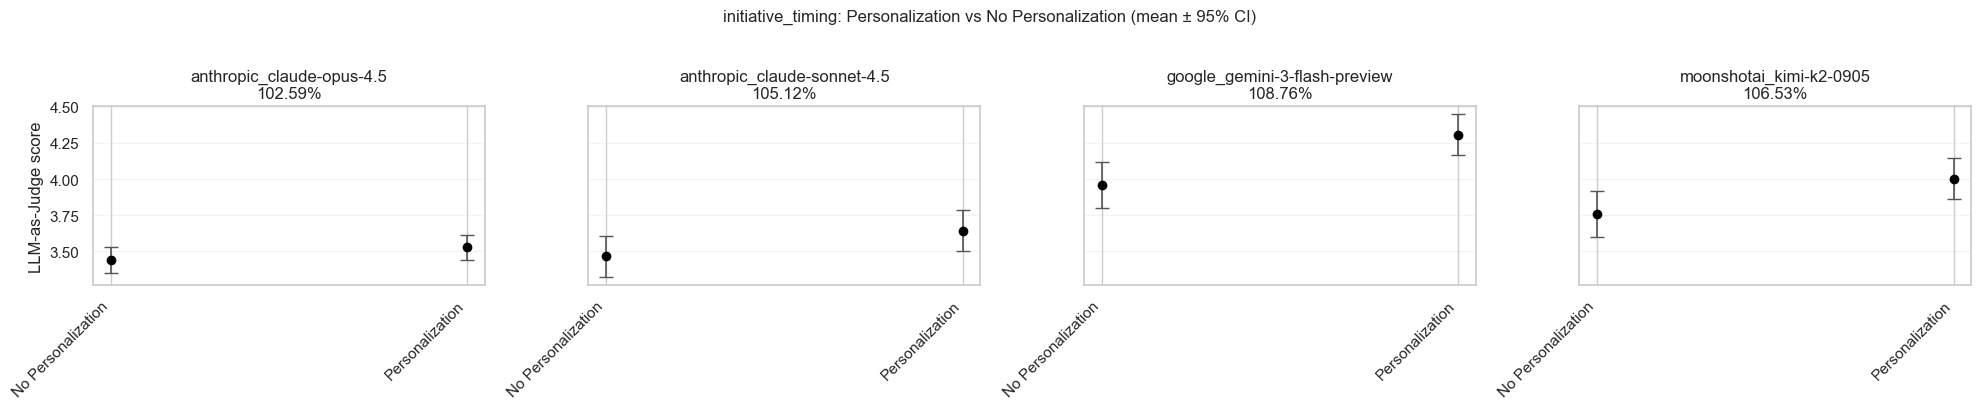

anthropic_claude-opus-4.5 - interaction_coherence: Ratio: 101.87%
anthropic_claude-sonnet-4.5 - interaction_coherence: Ratio: 101.61%
google_gemini-3-flash-preview - interaction_coherence: Ratio: 101.16%
moonshotai_kimi-k2-0905 - interaction_coherence: Ratio: 101.92%


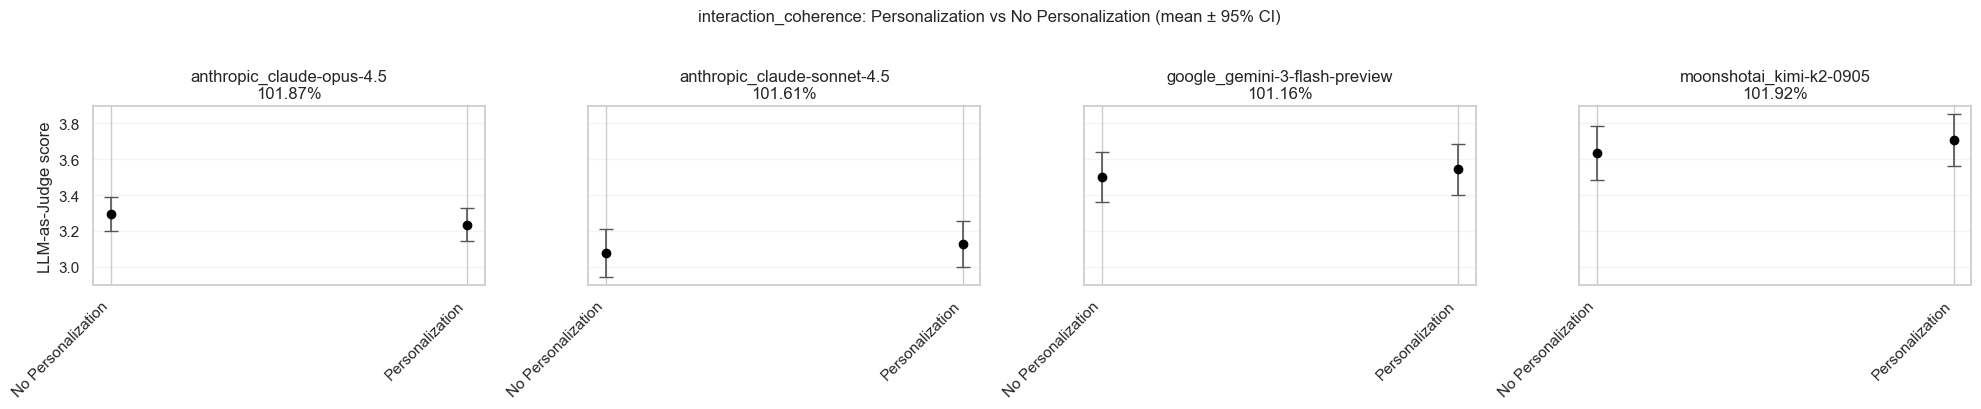

anthropic_claude-opus-4.5 - intent_alignment_drift: Ratio: 100.09%
anthropic_claude-sonnet-4.5 - intent_alignment_drift: Ratio: 101.24%
google_gemini-3-flash-preview - intent_alignment_drift: Ratio: 102.64%
moonshotai_kimi-k2-0905 - intent_alignment_drift: Ratio: 101.00%


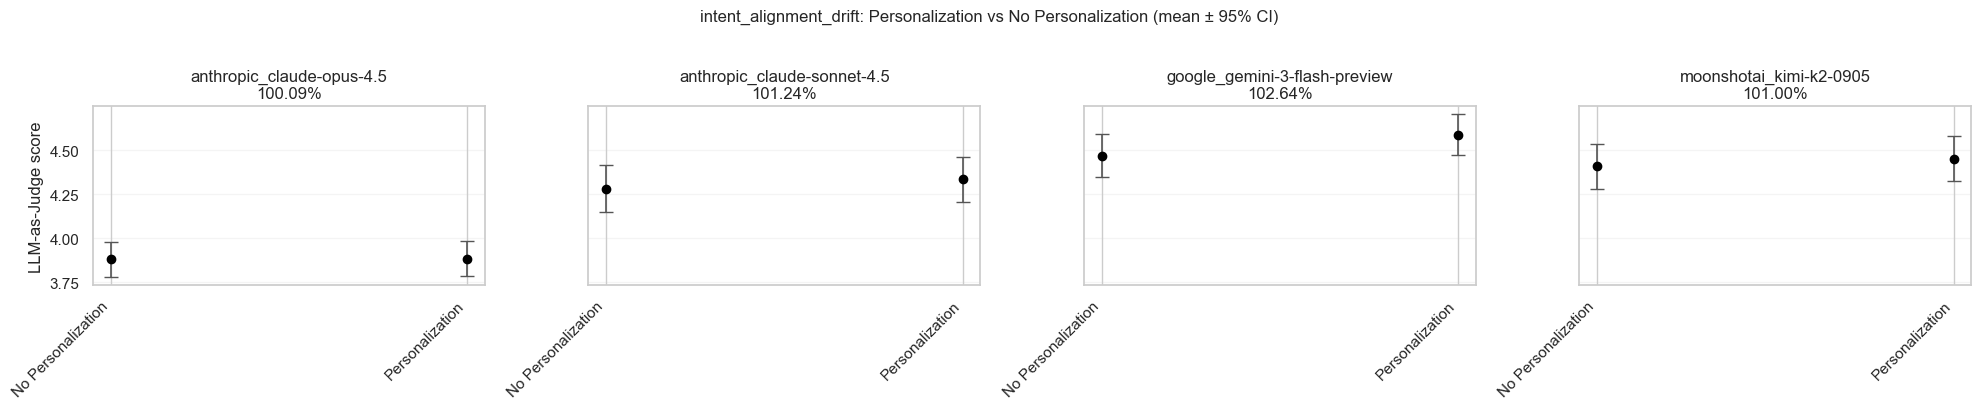

anthropic_claude-opus-4.5 - commitment_consistency: Ratio: 100.37%
anthropic_claude-sonnet-4.5 - commitment_consistency: Ratio: 103.33%
google_gemini-3-flash-preview - commitment_consistency: Ratio: 101.61%
moonshotai_kimi-k2-0905 - commitment_consistency: Ratio: 104.96%


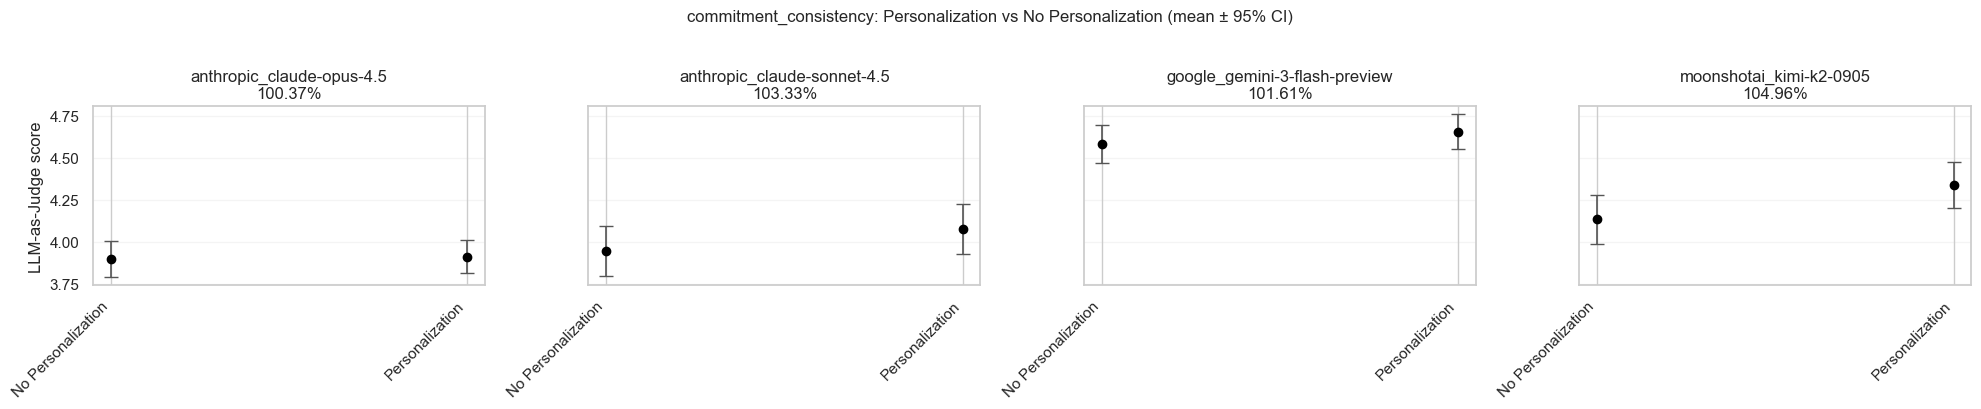

anthropic_claude-opus-4.5 - interaction_preference_alignment: Ratio: 114.55%
anthropic_claude-sonnet-4.5 - interaction_preference_alignment: Ratio: 121.28%
google_gemini-3-flash-preview - interaction_preference_alignment: Ratio: 113.83%
moonshotai_kimi-k2-0905 - interaction_preference_alignment: Ratio: 116.08%


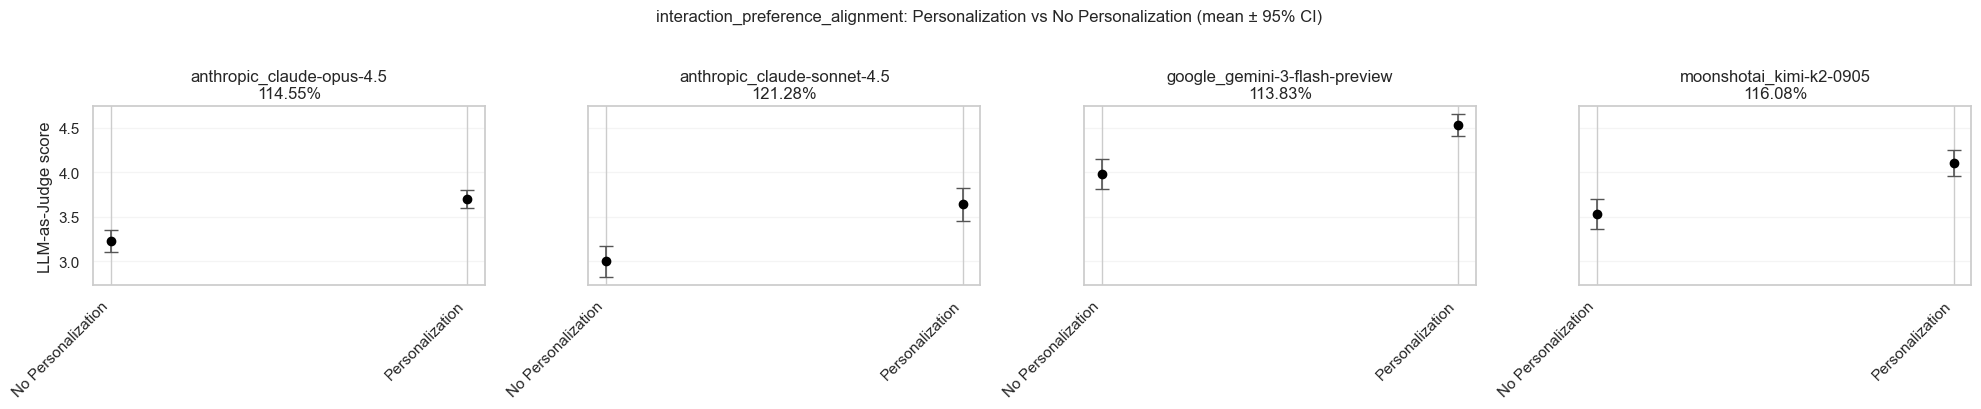

anthropic_claude-opus-4.5 - interaction_efficiency: Ratio: 101.15%
anthropic_claude-sonnet-4.5 - interaction_efficiency: Ratio: 100.99%
google_gemini-3-flash-preview - interaction_efficiency: Ratio: 106.38%
moonshotai_kimi-k2-0905 - interaction_efficiency: Ratio: 100.25%


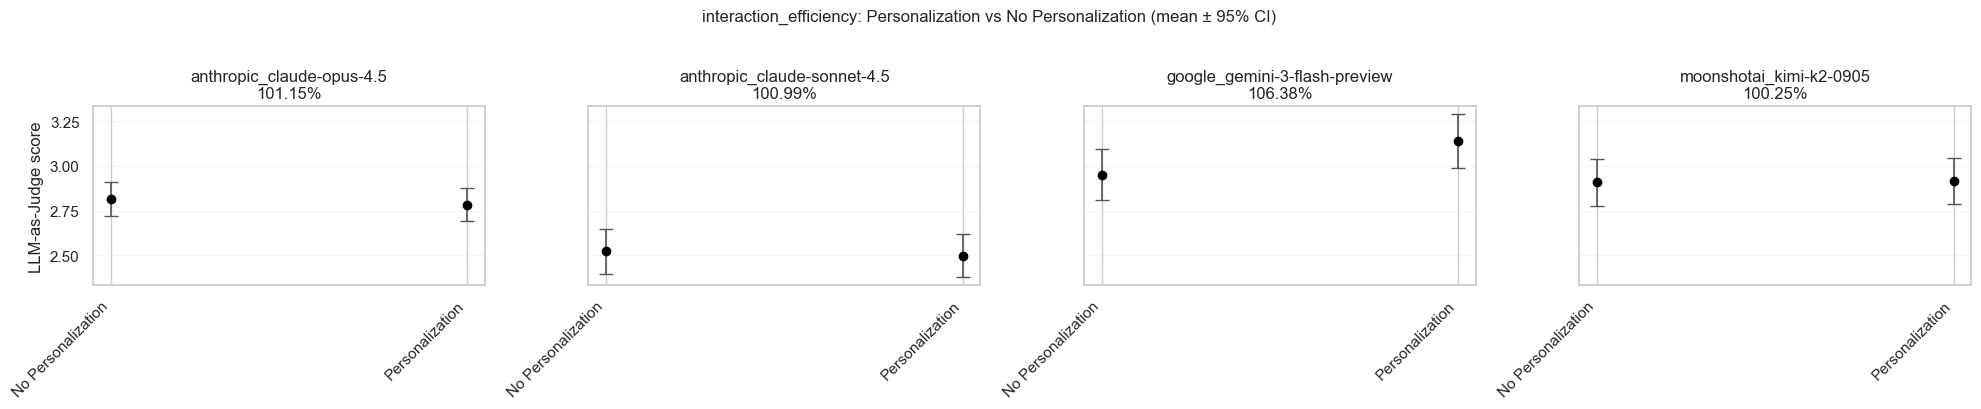

anthropic_claude-opus-4.5 - user_cognitive_load_trajectory: Ratio: 100.92%
anthropic_claude-sonnet-4.5 - user_cognitive_load_trajectory: Ratio: 104.21%
google_gemini-3-flash-preview - user_cognitive_load_trajectory: Ratio: 109.09%
moonshotai_kimi-k2-0905 - user_cognitive_load_trajectory: Ratio: 108.53%


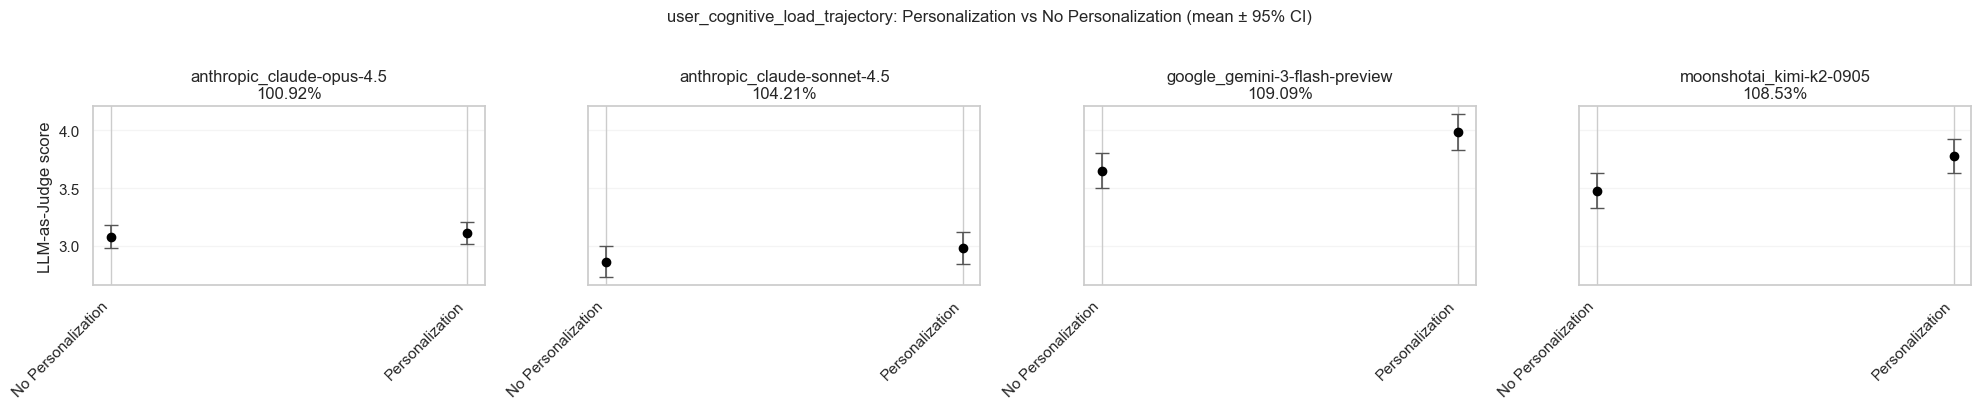

anthropic_claude-opus-4.5 - overall_user_experience: Ratio: 105.30%
anthropic_claude-sonnet-4.5 - overall_user_experience: Ratio: 109.64%
google_gemini-3-flash-preview - overall_user_experience: Ratio: 109.54%
moonshotai_kimi-k2-0905 - overall_user_experience: Ratio: 110.82%


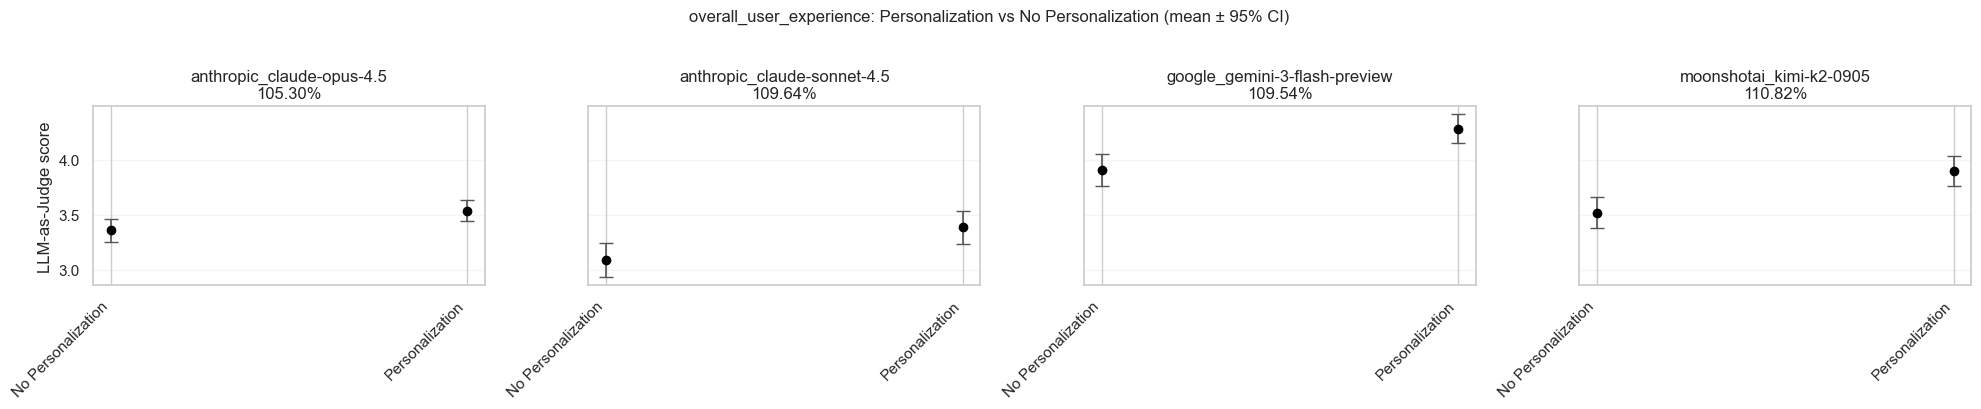

In [40]:
import matplotlib.pyplot as plt
import numpy as np

def plot_condition_errorbar_multimodel(merged_data_dict, dimension, ci=0.95, use_se=False):
    """
    Plot mean score for a dimension under two conditions with error bars for multiple judge models side by side.
    merged_data_dict: dict of {judge_name: merged_dataframe}
    """
    judge_names = list(merged_data_dict.keys())
    n_judges = len(judge_names)
    
    if n_judges == 0:
        raise ValueError("No merged data provided")
    
    fig, axes = plt.subplots(1, n_judges, figsize=(5 * n_judges, 4), sharey=True)
    if n_judges == 1:
        axes = [axes]
    
    z = 1.96 if not use_se else 1.0
    
    all_ratios = []
    
    for idx, judge_name in enumerate(judge_names):
        merged = merged_data_dict[judge_name]
        no_col = f"{dimension}_no"
        p_col = f"{dimension}_p"
        
        if no_col not in merged.columns or p_col not in merged.columns:
            axes[idx].text(0.5, 0.5, f"Missing data\nfor {judge_name}", 
                          ha='center', va='center', transform=axes[idx].transAxes)
            axes[idx].set_title(f"{judge_name}")
            continue
        
        df = merged[[no_col, p_col]].dropna()
        vals = {
            "No Personalization": df[no_col].values,
            "Personalization": df[p_col].values,
        }
        
        means, errs, labels = [], [], []
        for label, arr in vals.items():
            mean = np.mean(arr) if len(arr) else np.nan
            sem = np.std(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
            err = sem * z if not use_se else sem
            labels.append(label)
            means.append(mean)
            errs.append(err)
        
        # Calculate ratio
        no_mean = means[0]
        p_mean = means[1]
        
        if p_mean >= no_mean:
            ratio = p_mean / no_mean if no_mean != 0 else np.nan
            ratio_text = f"{ratio * 100:.2f}%"
        else:
            ratio = no_mean / p_mean if p_mean != 0 else np.nan
            ratio_text = f"{ratio * 100:.2f}%"
        
        all_ratios.append(ratio_text)
        
        # Print ratio for each judge
        print(f"{judge_name} - {dimension}: Ratio: {ratio_text}")
        
        x = np.arange(len(labels))
        axes[idx].errorbar(
            x, means, yerr=errs, fmt="o", capsize=5, color="black", ecolor="#555",
            elinewidth=1.2, markersize=6,
        )
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(labels, rotation=45, ha='right')
        axes[idx].set_ylabel("LLM-as-Judge score" if idx == 0 else "")
        axes[idx].set_title(f"{judge_name}\n{ratio_text}")
        axes[idx].grid(axis="y", alpha=0.2)
    
    fig.suptitle(f"{dimension}: Personalization vs No Personalization (mean ± {'SE' if use_se else '95% CI'})", 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# Run for all dimensions
for dim in DIMENSIONS:
    plot_condition_errorbar_multimodel(merged_data, dim, ci=0.95, use_se=False)

In [41]:
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_sorted_delta_curve(merged, dimension):
#     delta_col = f"delta_{dimension}"
#     if delta_col not in merged.columns:
#         raise KeyError(f"Missing column: {delta_col}")

#     deltas = merged[delta_col].dropna().to_numpy()
#     deltas_sorted = np.sort(deltas)  # ascending
#     x = np.arange(len(deltas_sorted))

#     n_neg = np.sum(deltas_sorted < 0)
#     n_pos = np.sum(deltas_sorted > 0)
#     n_zero = np.sum(deltas_sorted == 0)

#     plt.figure(figsize=(7, 4))
#     plt.plot(x, deltas_sorted, color="#1f77b4", linewidth=1.5)
#     plt.axhline(0, color="black", linewidth=1)

#     # optional shading to emphasize negatives vs positives
#     plt.fill_between(x, deltas_sorted, 0, where=deltas_sorted < 0, color="#d62728", alpha=0.2)
#     plt.fill_between(x, deltas_sorted, 0, where=deltas_sorted > 0, color="#1f77b4", alpha=0.15)

#     plt.ylabel(f"Δ {dimension} (personalization - no)")
#     plt.xlabel("test (sorted by delta)")
#     plt.title(
#         f"{dimension}: sorted deltas (neg: {n_neg}, zero: {n_zero}, pos: {n_pos})"
#     )
#     plt.grid(axis="y", alpha=0.25)
#     plt.tight_layout()
#     plt.show()

# # run for all dimensions
# for dim in DIMENSIONS:
#     plot_sorted_delta_curve(merged, dim)

### Single PERSONA analysis

In [42]:
def mean_across_judges(data_dict, label):
    frames = []
    for judge, df in data_dict.items():
        if target_dim not in df.columns:
            continue
        tmp = df[["test_id", "persona", target_dim]].copy()
        tmp["judge"] = judge
        frames.append(tmp)
    if not frames:
        raise ValueError(f"No data: {label}")
    all_scores = pd.concat(frames, ignore_index=True)
    per_sample = (
        all_scores.groupby(["test_id", "persona"])[target_dim]
        .mean()
        .reset_index(name="mean_score_across_judges")
    )
    overall_mean = per_sample["mean_score_across_judges"].mean()
    return per_sample, overall_mean

# Compute per-sample mean across judges, then global mean and personalization/no_personalization ratio
for target_dim in DIMENSIONS:
    print(f"=== {target_dim} ===")
    no_sample_mean, no_overall_mean = mean_across_judges(no_personalization_data, "no_personalization")
    p_sample_mean, p_overall_mean = mean_across_judges(personalization_data, "personalization")
    ratio = p_overall_mean / no_overall_mean if no_overall_mean else np.nan
    print("No personalization overall mean:", no_overall_mean)
    print("Personalization overall mean:", p_overall_mean)
    print("Personalization / No personalization ratio:", ratio)
    print("\nPer-sample mean across judges (no_personalization):")
    # display(no_sample_mean.head())
    # print("\nPer-sample mean across judges (personalization):")
    # display(p_sample_mean.head())
    # print("\n\n")




=== initiative_timing ===
No personalization overall mean: 3.653664302600473
Personalization overall mean: 3.870567375886525
Personalization / No personalization ratio: 1.0593659010029115

Per-sample mean across judges (no_personalization):
=== interaction_coherence ===
No personalization overall mean: 3.381205673758865
Personalization overall mean: 3.4069148936170213
Personalization / No personalization ratio: 1.007603565810173

Per-sample mean across judges (no_personalization):
=== intent_alignment_drift ===
No personalization overall mean: 4.263888888888888
Personalization overall mean: 4.3170803782505915
Personalization / No personalization ratio: 1.0124748769838523

Per-sample mean across judges (no_personalization):
=== commitment_consistency ===
No personalization overall mean: 4.137115839243498
Personalization overall mean: 4.247340425531915
Personalization / No personalization ratio: 1.0266428571428572

Per-sample mean across judges (no_personalization):
=== interaction_prefe

In [43]:
# Compute overall mean and ratio per dimension and put into a new DataFrame

dim_list = []
no_means = []
p_means = []
ratios = []

for target_dim in DIMENSIONS:
    no_sample_mean, no_overall_mean = mean_across_judges(no_personalization_data, "no_personalization")
    p_sample_mean, p_overall_mean = mean_across_judges(personalization_data, "personalization")
    ratio = 100*(p_overall_mean / no_overall_mean) if no_overall_mean else np.nan

    dim_list.append(target_dim)
    no_means.append(no_overall_mean)
    p_means.append(p_overall_mean)
    ratios.append(ratio)

df_compare = pd.DataFrame({
    "dimension": dim_list,
    "no_personalization": no_means,
    "personalization": p_means,
    "ratio": ratios,
})
display(df_compare)


,dimension,no_personalization,personalization,ratio
0,initiative_timing,3.653664,3.870567,105.936590
1,interaction_coherence,3.381206,3.406915,100.760357
2,intent_alignment_drift,4.263889,4.317080,101.247488
3,commitment_consistency,4.137116,4.247340,102.664286
4,interaction_preference_alignment,3.428783,3.983452,116.176851
5,interaction_efficiency,2.804965,2.837766,101.169406
6,user_cognitive_load_trajectory,3.269208,3.462175,105.902558
7,overall_user_experience,3.469563,3.776891,108.857849


In [44]:
# df_compare.to_csv(
#     "<PROJECT_ROOT>/Desktop/Desktop - ADUAED19365LPMX/Agent_IX_Personalization/gorilla/berkeley-function-call-leaderboard/bfcl_eval/LLM_as_judge_analysis/compare/df_compare_sonnet.csv",
#     index=False
# )


## Persona-level judge variation
For each persona and each UX dimension, compute across-judge mean and variability (per judge averaged over test cases).

In [45]:
def persona_judge_variation(data_dict: dict) -> pd.DataFrame:
    rows = []
    for judge, df in data_dict.items():
        # melt dimensions to long
        long_df = df.melt(id_vars=["test_id", "persona"], value_vars=DIMENSIONS, var_name="dimension", value_name="score")
        # average over test cases per persona/dimension for this judge
        per_judge = long_df.groupby(["persona", "dimension"], as_index=False)["score"].mean()
        per_judge["judge_model"] = judge
        rows.append(per_judge)
    if not rows:
        return pd.DataFrame(columns=["persona", "dimension", "mean_over_tests", "std_across_judges", "n_judges"])
    all_judge = pd.concat(rows, ignore_index=True)
    # aggregate across judges: mean of judge means, std across judges
    agg = (
        all_judge
        .groupby(["persona", "dimension"])
        .agg(
            mean_over_tests=("score", "mean"),
            std_across_judges=("score", "std"),
            n_judges=("judge_model", "nunique"),
        )
        .reset_index()
    )
    return agg

persona_variation_no = persona_judge_variation(no_personalization_data)
persona_variation_p = persona_judge_variation(personalization_data)

print("No personalization: persona × dimension across-judge stats (head)")
display(persona_variation_no.head())
print("Personalization: persona × dimension across-judge stats (head)")
display(persona_variation_p.head())


No personalization: persona × dimension across-judge stats (head)


,persona,dimension,mean_over_tests,std_across_judges,n_judges
0,chain_parallel,commitment_consistency,3.575,0.287228,4
1,chain_parallel,initiative_timing,2.525,0.386221,4
2,chain_parallel,intent_alignment_drift,3.725,0.386221,4
3,chain_parallel,interaction_coherence,2.925,0.309570,4
4,chain_parallel,interaction_efficiency,2.375,0.340343,4


Personalization: persona × dimension across-judge stats (head)


,persona,dimension,mean_over_tests,std_across_judges,n_judges
0,chain_parallel,commitment_consistency,4.375,0.464579,4
1,chain_parallel,initiative_timing,3.225,0.543906,4
2,chain_parallel,intent_alignment_drift,4.250,0.544671,4
3,chain_parallel,interaction_coherence,3.200,0.408248,4
4,chain_parallel,interaction_efficiency,2.575,0.377492,4


In [46]:
persona_variation_p

,persona,dimension,mean_over_tests,std_across_judges,n_judges
0,chain_parallel,commitment_consistency,4.37500,0.464579,4
1,chain_parallel,initiative_timing,3.22500,0.543906,4
2,chain_parallel,intent_alignment_drift,4.25000,0.544671,4
3,chain_parallel,interaction_coherence,3.20000,0.408248,4
4,chain_parallel,interaction_efficiency,2.57500,0.377492,4
...,...,...,...,...,...
243,tool_switch_low_agency,interaction_coherence,3.87500,0.530330,4
244,tool_switch_low_agency,interaction_efficiency,3.00000,0.367990,4
245,tool_switch_low_agency,interaction_preference_alignment,3.87500,0.822851,4
246,tool_switch_low_agency,overall_user_experience,3.96875,0.514123,4


## Persona gain by dimension
Compare personalization vs. no_personalization for each persona × dimension by averaging scores across judges and test cases, then compute lift (delta).

In [47]:
def persona_dim_mean_across_judges(data_dict: dict) -> pd.DataFrame:
    rows = []
    for judge, df in data_dict.items():
        long_df = df.melt(id_vars=["test_id", "persona"], value_vars=DIMENSIONS, var_name="dimension", value_name="score")
        per_judge = long_df.groupby(["persona", "dimension"], as_index=False)["score"].mean()
        per_judge["judge_model"] = judge
        rows.append(per_judge)
    if not rows:
        return pd.DataFrame(columns=["persona", "dimension", "mean_score"])
    all_judge = pd.concat(rows, ignore_index=True)
    return (
        all_judge.groupby(["persona", "dimension"], as_index=False)["score"]
        .mean()
        .rename(columns={"score": "mean_score"})
    )

mean_no = persona_dim_mean_across_judges(no_personalization_data)
mean_p = persona_dim_mean_across_judges(personalization_data)

persona_delta = mean_no.merge(mean_p, on=["persona", "dimension"], suffixes=("_no", "_p"))
persona_delta["delta"] = persona_delta["mean_score_p"] - persona_delta["mean_score_no"]

# Overall best/worst lifts (all dimensions pooled)
overall_delta = persona_delta.groupby("persona").agg(overall_delta=("delta", "mean")).reset_index()
print("Top 10 personas by average delta across dimensions:")
display(overall_delta.sort_values("overall_delta", ascending=False).head(10))
print("Bottom 10 personas by average delta across dimensions:")
display(overall_delta.sort_values("overall_delta", ascending=True).head(10))

# For each dimension: top/bottom personas
for dim in DIMENSIONS:
    sub = persona_delta[persona_delta["dimension"] == dim]
    if sub.empty:
        continue
    print(f"\n=== {dim}: top 5 positive deltas ===")
    display(sub.sort_values("delta", ascending=False).head(5))
    print(f"=== {dim}: bottom 5 (negative/small) deltas ===")
    display(sub.sort_values("delta", ascending=True).head(5))


Top 10 personas by average delta across dimensions:


,persona,overall_delta
22,tool_high,1.093750
8,error_retry_escalation,0.875000
25,tool_invocation_multiple,0.593750
5,each_confirmation,0.587153
1,chain_sequential,0.514062
0,chain_parallel,0.512500
13,param_low,0.503125
21,tool_abortion_stop,0.425347
3,disambiguation_gradual,0.379464
2,confirmation_batch,0.331250


Bottom 10 personas by average delta across dimensions:


,persona,overall_delta
7,error_discovery_detail,-0.428125
26,tool_invocation_single,-0.277344
20,tool_abortion_continue,-0.250000
9,error_retry_silent,-0.242188
17,silent,-0.190972
6,error_discovery_brief,-0.106250
15,presentation_compact,-0.037500
23,tool_initiative_proactive,0.009722
19,source_low,0.028646
14,param_medium,0.031250



=== initiative_timing: top 5 positive deltas ===


...

,persona,dimension,mean_score_no,mean_score_p,delta
63,error_discovery_detail,user_cognitive_load_trajectory,4.175000,3.60000,-0.575000
215,tool_invocation_single,user_cognitive_load_trajectory,3.406250,2.84375,-0.562500
167,tool_abortion_continue,user_cognitive_load_trajectory,3.647222,3.15000,-0.497222
79,error_retry_silent,user_cognitive_load_trajectory,2.937500,2.56250,-0.375000
127,presentation_compact,user_cognitive_load_trajectory,3.375000,3.22500,-0.150000



=== overall_user_experience: top 5 positive deltas ===


,persona,dimension,mean_score_no,mean_score_p,delta
182,tool_high,overall_user_experience,2.892857,4.785714,1.892857
70,error_retry_escalation,overall_user_experience,3.250000,4.375000,1.125000
206,tool_invocation_multiple,overall_user_experience,3.343750,4.187500,0.843750
46,each_confirmation,overall_user_experience,3.938889,4.750000,0.811111
14,chain_sequential,overall_user_experience,3.275000,4.075000,0.800000


=== overall_user_experience: bottom 5 (negative/small) deltas ===


,persona,dimension,mean_score_no,mean_score_p,delta
214,tool_invocation_single,overall_user_experience,3.562500,3.0625,-0.500000
166,tool_abortion_continue,overall_user_experience,4.211111,3.7750,-0.436111
142,silent,overall_user_experience,3.944444,3.6500,-0.294444
62,error_discovery_detail,overall_user_experience,4.150000,3.8750,-0.275000
54,error_discovery_brief,overall_user_experience,3.650000,3.5000,-0.150000


In [48]:
sub = persona_delta[persona_delta["dimension"] == "intent_alignment_drift"]

In [49]:
# Define mapping from persona to Category
persona_category_map = {
    # 1. Transparency & Auditability
    "tool_high": "Transparency & Auditability",
    "tool_medium": "Transparency & Auditability",
    "tool_low": "Transparency & Auditability",
    "param_high": "Transparency & Auditability",
    "param_medium": "Transparency & Auditability",
    "param_low": "Transparency & Auditability",
    "source_high": "Transparency & Auditability",
    "source_low": "Transparency & Auditability",
    "error_discovery_brief": "Transparency & Auditability",
    "error_discovery_detail": "Transparency & Auditability",

    # 2. Interaction Pace & Flow
    "info_collect_gradual": "Interaction Pace & Flow",
    "info_collect_upfront": "Interaction Pace & Flow",
    "disambiguation_gradual": "Interaction Pace & Flow",
    "disambiguation_upfront": "Interaction Pace & Flow",
    "each_confirmation": "Interaction Pace & Flow",
    "confirmation_batch": "Interaction Pace & Flow",
    "silent": "Interaction Pace & Flow",
    "chain_parallel": "Interaction Pace & Flow",
    "chain_sequential": "Interaction Pace & Flow",
    "presentation_compact": "Interaction Pace & Flow",
    "presentation_layered": "Interaction Pace & Flow",

    # 3. Strategy & Initiative
    "tool_initiative_proactive": "Strategy & Initiative",
    "tool_initiative_reactive": "Strategy & Initiative",
    "tool_invocation_single": "Strategy & Initiative",
    "tool_invocation_multiple": "Strategy & Initiative",

    # 4. Robustness & Adaptability
    "error_retry_silent": "Robustness & Adaptability",
    "error_retry_escalation": "Robustness & Adaptability",
    "error_retry_hybrid": "Robustness & Adaptability",
    "tool_abortion_stop": "Robustness & Adaptability",
    "tool_abortion_continue": "Robustness & Adaptability",
    "tool_switch_high_agency": "Robustness & Adaptability",
    "tool_switch_low_agency": "Robustness & Adaptability",
}

# Add Category column to sub
sub_with_category = sub.copy()
sub_with_category["category"] = sub_with_category["persona"].map(persona_category_map).fillna("Other")

# Reorder columns: category first
cols = ["category"] + [col for col in sub_with_category.columns if col != "category"]
display(sub_with_category[cols].sort_values("delta", ascending=False))


,category,persona,dimension,mean_score_no,mean_score_p,delta
178,Transparency & Auditability,tool_high,intent_alignment_drift,4.000000,4.964286,0.964286
202,Strategy & Initiative,tool_invocation_multiple,intent_alignment_drift,3.906250,4.500000,0.593750
2,Interaction Pace & Flow,chain_parallel,intent_alignment_drift,3.725000,4.250000,0.525000
34,Interaction Pace & Flow,disambiguation_upfront,intent_alignment_drift,3.535714,3.964286,0.428571
98,Transparency & Auditability,param_high,intent_alignment_drift,4.357143,4.750000,0.392857
66,Robustness & Adaptability,error_retry_escalation,intent_alignment_drift,4.062500,4.437500,0.375000
170,Robustness & Adaptability,tool_abortion_stop,intent_alignment_drift,4.425000,4.800000,0.375000
234,Robustness & Adaptability,tool_switch_high_agency,intent_alignment_drift,3.834821,4.187500,0.352679
226,Transparency & Auditability,tool_medium,intent_alignment_drift,4.375000,4.725000,0.350000
82,Interaction Pace & Flow,info_collect_gradual,intent_alignment_drift,4.225000,4.556250,0.331250


In [50]:
# Group by category and compute mean delta per category
category_delta_mean = sub_with_category.groupby("category")["delta"].mean()
print("Mean delta by category:")
print(category_delta_mean.sort_values(ascending=False))


各类category的平均delta如下：
category
Transparency & Auditability    0.081131
Interaction Pace & Flow        0.073169
Strategy & Initiative          0.070486
Robustness & Adaptability      0.056465
Name: delta, dtype: float64
